# To plot the $\sigma$68 of the $df$ in PAUS bands before and after denoising with LoRA-N2V.

The data we used is from all the PAUS bands. Since the data is too large, we sampled a subset.

In [1]:
import os
import pandas as pd
from pathlib import Path
import psycopg2
from matplotlib import pyplot as plt
import copy
import math
from scipy.stats import norm
import numpy as np

In [2]:
def cal_calerror(sig_src,sig_zp,zp,f_src):
    sig_cal = np.sqrt(sig_src**2 * sig_zp**2 + sig_src**2 * zp**2 + sig_zp**2 * f_src**2)
    return sig_cal

def cal_fcal(f_src,zp):
    f_cal = f_src * zp
    return f_cal

In [3]:
path = '../data saved/'

In [4]:
combined_faint1 = pd.read_csv(path + 'bands_denoisedfaint_part1.csv')
combined_faint2 = pd.read_csv(path + 'bands_denoisedfaint_part2.csv')
combined_median = pd.read_csv(path + 'bands_denoisedmedian.csv')
combined_bright = pd.read_csv(path + 'bands_denoisedbright.csv')

In [5]:
combined = pd.concat([combined_faint1, combined_faint2, combined_median,
                            combined_bright], axis=0, ignore_index=True)
combined = combined.reset_index(drop=True)

In [6]:
comb = pd.merge(combined,combined,on = ['ref_id','filter'])
comb['df'] = (comb['flux_ca_x'] - comb['flux_ca_y'])/np.sqrt(comb['flux_ca_error_x']**2 + comb['flux_ca_error_y']**2)
comb = comb[comb.image_id_x != comb.image_id_y]

In [7]:
combined['flux_ca_error'] = cal_calerror(combined['flux_error'],combined['zp_error'],combined['zp'],combined['flux_obs'])
combined['flux_ca'] = cal_fcal(combined['flux_obs'],combined['zp'])

combined['flux_ca_error_obs'] = cal_calerror(combined['flux_error'],combined['zp_error'],combined['zp'],combined['flux_obs_denoised'])
combined['flux_ca_obs'] = cal_fcal(combined['flux_obs_denoised'],combined['zp'])

combb = pd.merge(combined,combined,on = ['ref_id','filter'])
combb['df1'] = (combb['flux_ca_x'] - combb['flux_ca_y'])/np.sqrt(combb['flux_ca_error_x']**2 + combb['flux_ca_error_y']**2)
combb['df2'] = (combb['flux_ca_obs_x'] - combb['flux_ca_obs_y'])/np.sqrt(combb['flux_ca_error_x']**2 + combb['flux_ca_error_y']**2)
combb = combb[combb.image_id_x != combb.image_id_y]

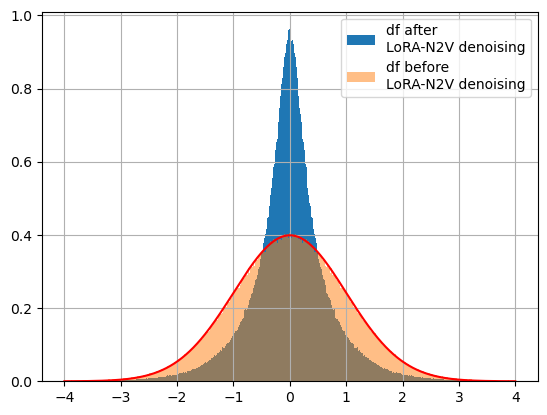

In [8]:
combb.df2.hist(bins=np.linspace(-4, 4,500), density=True,label='df after \nLoRA-N2V denoising')
comb.df.hist(bins=np.linspace(-4, 4,500), density=True,alpha = 0.5, label = 'df before \nLoRA-N2V denoising')

x = np.linspace(-4, 4, 33266)
y = norm.pdf(x)
plt.plot(x, y,color='red')
plt.legend()

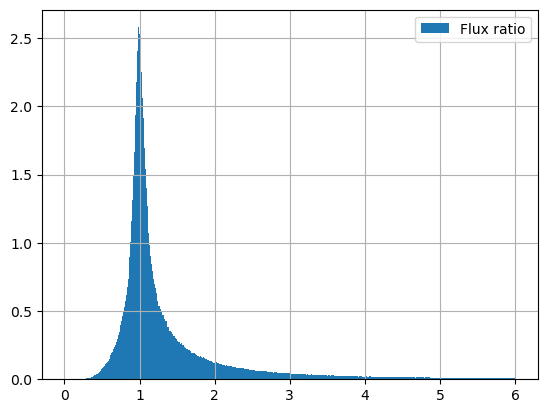

In [9]:
flux_ratio_df1 = pd.DataFrame({
    'flux_ratio': combined['flux_obs_denoised'] / combined['flux_obs']})
filtered = flux_ratio_df1[(flux_ratio_df1['flux_ratio'] > 0)&(flux_ratio_df1['flux_ratio'] <3)]
flux_ratio_df1.flux_ratio.hist(bins=np.linspace(-0, 6,500), density=True,label = 'Flux ratio')
plt.legend()

<Figure size 1200x500 with 0 Axes>

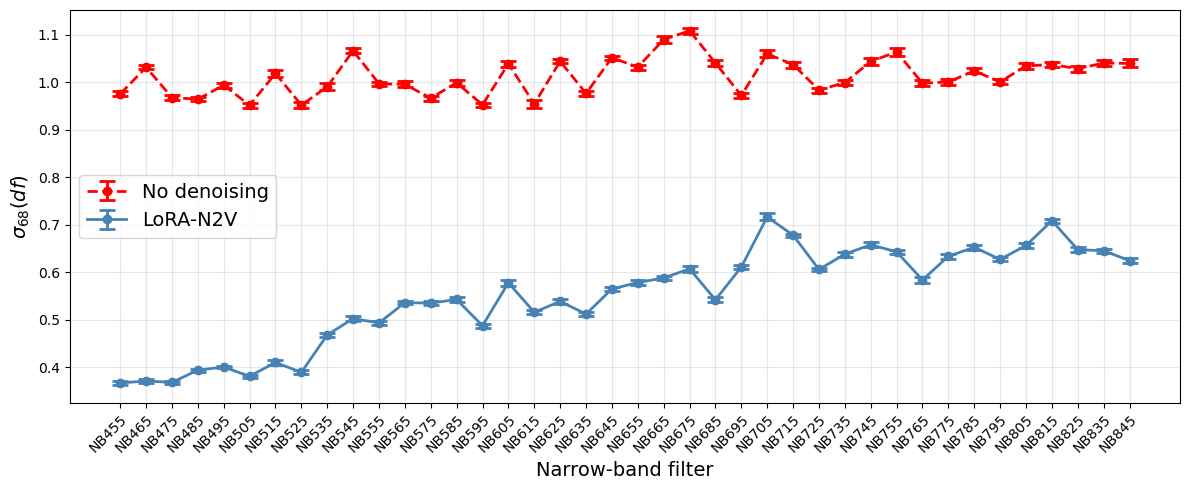

In [11]:
def sigma68(data):
    data_clean = data.dropna()
    if len(data_clean) == 0:
        return np.nan
    p16 = np.percentile(data_clean, 16)
    p84 = np.percentile(data_clean, 84)
    return (p84 - p16) / 2

def get_sigma68_with_error(data, n_boot=20):
    data_clean = data.dropna().values
    n_samples = len(data_clean)
    
    if n_samples < 3:
        return pd.Series({'sigma68_val': sigma68(data), 'sigma68_err': 0.0})
        
    actual_sigma68 = sigma68(data)
    
    boot_sigmas = []
    for _ in range(n_boot):
        boot_sample = np.random.choice(data_clean, size=n_samples, replace=True)
        boot_sigmas.append(sigma68(pd.Series(boot_sample)))
        
    sigma68_err = np.std(boot_sigmas)
    
    return pd.Series({'sigma68_val': actual_sigma68, 'sigma68_err': sigma68_err})

res_denoise = combb.groupby('filter')['df2'].apply(get_sigma68_with_error).unstack().reset_index()
res_denoise['filter_num'] = res_denoise['filter'].str.extract(r'(\d+)').astype(int)
res_denoise = res_denoise.sort_values('filter_num')

res_ori = combb.groupby('filter')['df1'].apply(get_sigma68_with_error).unstack().reset_index()
res_ori['filter_num'] = res_ori['filter'].str.extract(r'(\d+)').astype(int)
res_ori = res_ori.sort_values('filter_num')

plt.figure(figsize=(12, 5))

plt.figure(figsize=(12, 5))

plt.errorbar(res_ori['filter'], res_ori['sigma68_val'], yerr=res_ori['sigma68_err'],
             marker='o', linestyle='--', linewidth=2, markersize=6, color='red', label='No denoising', 
             capsize=6, elinewidth=2, capthick=2) 

plt.errorbar(res_denoise['filter'], res_denoise['sigma68_val'], yerr=res_denoise['sigma68_err'],
             marker='o', linestyle='-', linewidth=2, markersize=6, color='steelblue', label='LoRA-N2V', 
             capsize=6, elinewidth=2, capthick=2) 

plt.xlabel('Narrow-band filter', fontsize=14)
plt.ylabel(r'$\sigma_{68}(df)$', fontsize=14) 
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.grid(True, alpha=0.3)
plt.legend(loc='center left', fontsize=14)
plt.tight_layout()
#plt.savefig("/data/aai/scratch/jchan/denoise/PAUS/output_save/bandssigma68.pdf",format="pdf", bbox_inches="tight")

plt.show()